# Block Blast RL Environment Testing

This notebook demonstrates the Block Blast Gymnasium environment. We'll instantiate the environment, show how to render it using `matplotlib` and `rgb_array` mode, and run a random agent to verify that the logic works continuously in a loop.

In [1]:
import sys
from pathlib import Path

# Add the nearest parent "src" directory to Python path
src_path = next((p / "src" for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()), None)

if src_path is None:
    raise FileNotFoundError("Could not find a 'src' directory in current path or parent directories.")

sys.path.insert(0, str(src_path))
print(f"Added to sys.path: {src_path}")

Added to sys.path: /users/eleves-b/2023/keyvan.attarian/RL_project/src


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from blockblast import BlockBlastEnv

In [3]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Environment Initialization

In [8]:
# Initialize with rgb_array mode which is best for Jupyter animation
env = BlockBlastEnv(render_mode="rgb_array", punish_for_invalid=-500)
obs, info = env.reset(
)

## 2. Random Agent Loop

Let's play for a few steps utilizing valid random moves.

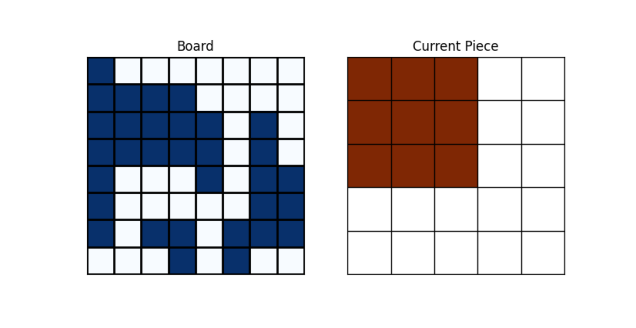


Game Terminated.

Final Reward: -455


In [9]:
obs, info = env.reset()  # We now properly capture the initial observation!
STEPS = 20
total_reward = 0

for step_idx in range(STEPS):
    # Render the rgb_array
    img = env.render()
    
    # Clear previous frame and draw new one
    clear_output(wait=True)
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    print(f"--- Step {step_idx + 1} ---")
    print(f"Current Total Reward: {total_reward}")
    
    # Efficiently find all valid actions from the observation mask
    valid_actions = np.flatnonzero(obs["valid_placements"])
    print(f"Valid Actions: {valid_actions}")
    if len(valid_actions) == 0:
        print("\nGame Over: No valid moves left.")
        break
        
    # Pick a random valid action
    action = np.random.choice(valid_actions)
    
    # Step
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    
    time.sleep(0.5)
    
    if terminated or truncated:
        # Last render on termination
        img = env.render()
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        print("\nGame Terminated.")
        break

print(f"\nFinal Reward: {total_reward}")
env.close()
